# Predicting childhood asthma with PM 2.5
## Work in progress

To get grounded in a health outcome with a known relationship to air pollution, I'm starting with the relationship between childhood asthma and PM 2.5 (particulate matter smaller than 2.5 microns).

The childhood asthma data comes from the [Western Pennsylvania Regional Data Center](https://data.wprdc.org/dataset/childhood-asthma-healthcare-utilization) (WPRDC) and covers Allegheny County for the year 2017. The data consist of counts of asthma related healthcare encounters over the entire year, as well as the overall number of children, localized by census tract.

The air pollution data comes from the [EPA's Environmental Justice Screen](https://www.epa.gov/ejscreen) [data archive](https://gaftp.epa.gov/EJScreen), as an average annual concentration in mg/m^3 localized by census block group. As documented [here](https://www.epa.gov/system/files/documents/2024-07/ejscreen-tech-doc-version-2-3.pdf), the PM 2.5 concentration estimates are derived from regional monitoring combined with the EPA's Community Multiscale Air Quality (CMAQ) air quality modeling. EJ Screen data also includes demographic information for the census block groups, such as fraction PoC and fraction low income.

Because census tracts are composed of census block groups, it is straightforward to convert the EJ Screen data to localization over census tracts.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.api as sm
from libpysal.weights import Queen, KNN
from esda.moran import Moran
import spreg

from air_brain.config import data_dir
from air_brain.tables import ols2df, spreg2df, p_col_style

In [2]:
# census tract geometry
tracts = gpd.read_file(data_dir / "tract_2010" / "tl_2010_42003_tract10.shp")
tracts.GEOID10 = tracts.GEOID10.astype(int)

## Asthma data

The WPRDC childhood asthma dataset includes, for the year 2017 and localized by census tract, counts of the number of children with at least one
- emergency department visit related to asthma `ED_visits`
- hospitalization post-emergency department visit related to asthma `ED_hosp`
- urgent care visit related to asthma `UC_visits`
- medical encounter of any kind related to asthma `Asthma_use`

as well as the total number of children who could have had a recorded medical encounter `Total_members`.

To generate the dependent variables, I divide the encounter counts by the total number of children, to give the fraction of children in that census tract who have had an asthma-related encounter in 2017.

In [3]:
# import the childhood asthma healthcare utilization data
asthma = pd.read_csv(data_dir / "asthma.csv")

# TODO should do this in preprocessing
# ED hospitalizations should be a subset of ED visits
# so if ED_visits < ED_hosp, set ED_visits to ED_hosp
asthma.loc[asthma.ED_visits < asthma.ED_hosp, "ED_visits"] = asthma.loc[asthma.ED_visits < asthma.ED_hosp, "ED_hosp"]
# convert all counts to fractions of potential patients
# if no members in census tract, fill with 0
for col in ["Asthma_use", "UC_visits", "ED_visits", "ED_hosp"]:
    asthma["{}_frac".format(col)] = (asthma[col] / asthma.Total_members).fillna(0)
# too little data, remove
asthma = asthma.loc[asthma.Total_members > 4]

dep_vars = ["ED_visits_frac", "ED_hosp_frac", "UC_visits_frac", "Asthma_use_frac"]

In [4]:
# add on the 2010 census tract geography for plotting
asthma_gpd = tracts.merge(asthma, left_on="GEOID10", right_on="Census_tract", how="right", validate="1:1")

Text(0.5, 1.0, 'Any asthma')

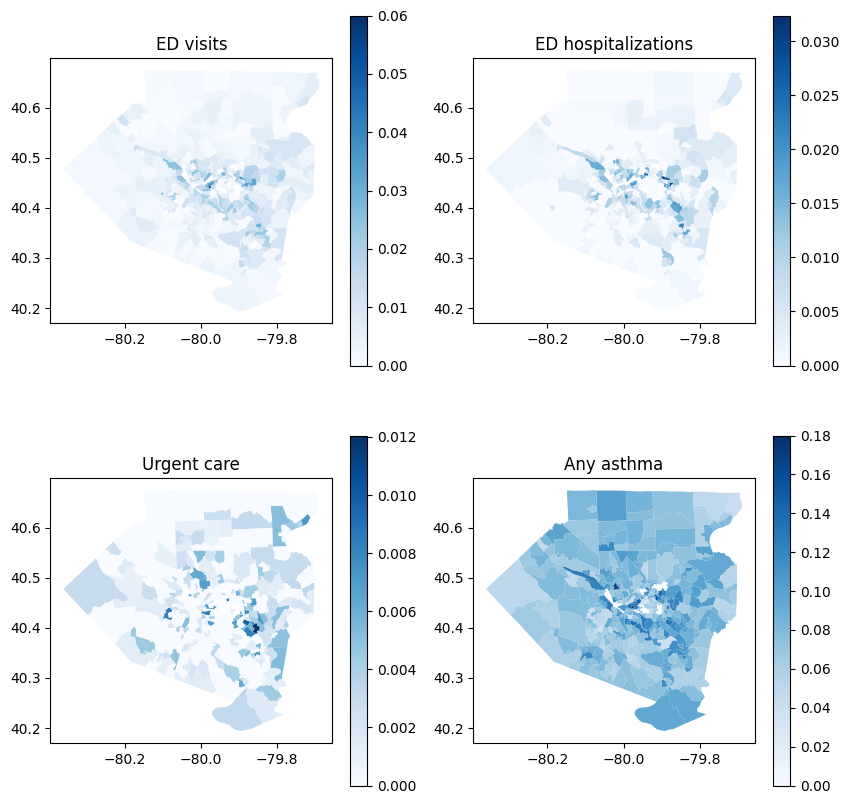

In [5]:
# plot the fraction of children who have at least one asthma encounter types, using Allegheny County geography
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
asthma_gpd.plot(column="ED_visits_frac", cmap="Blues", legend=True, ax=axs[0,0])
axs[0,0].set_title("ED visits")
asthma_gpd.plot(column="ED_hosp_frac", cmap="Blues", legend=True, ax=axs[0,1])
axs[0,1].set_title("ED hospitalizations")
asthma_gpd.plot(column="UC_visits_frac", cmap="Blues", legend=True, ax=axs[1,0])
axs[1,0].set_title("Urgent care")
asthma_gpd.plot(column="Asthma_use_frac", cmap="Blues", legend=True, ax=axs[1,1])
axs[1,1].set_title("Any asthma")

There is a tempting pattern of higher asthma encounters in the southeast region of Allegheny County. As we'll see below, this is also an area of higher PM 2.5 concentration from industrial activity.

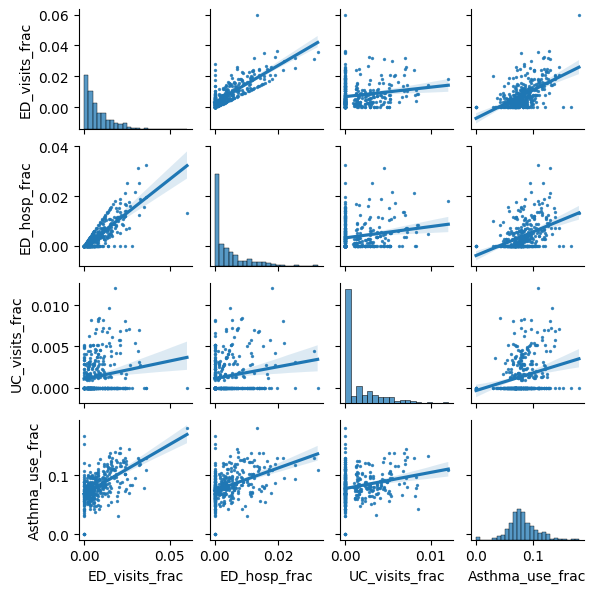

In [6]:
# plot relationships among our outcome variables
# this doesn't really affect the statistics later on, it's mostly context
sns.pairplot(asthma[dep_vars], height=1.5, kind="reg", plot_kws={"scatter_kws":{"s": 2}})

Fortunately, emergency department and urgent care visits are fairly rare. We see a strong positive skew to the distributions of these data. Overall asthma use is much more common, and has a much more normal distribution, than the emergency department or urgent care variables.

Interestingly, we actually see a higher fraction of children with emergency department visits and hospitalizations than we do urgent care visits. I would have assumed that higher acuity care would be rarer than lower acuity. I suspect this difference has more to do with socio-economics than it does medicine, and this hypothesis is supported with data below.

There are, unsurprisingly, positive correlations between all pairs of asthma variables.

## Air quality and demographics

The EPA's EJ Screen dataset includes PM 2.5 concentration estimations averaged annually and over census block groups. Census tracts are composed of unions of census block groups, so it is straightforward to average the PM 2.5 concentrations over census tracts to match the localization of the asthma data.

The EJ Screen data includes several variables related to air quality, including
- PM 2.5 `PM25`
- ozone `O3`
- nitrogen dioxide (but not for 2017)
- diesel particulate matter (a subset of PM 2.5) `dpm`
- traffic proximity `traffic`
- toxic releases to air

I am focusing on PM 2.5, diesel particulate matter, and traffic proximity, since these are [known risk factors in the development of childhood asthma](https://pmc.ncbi.nlm.nih.gov/articles/PMC7503605/). Nitrogen dioxide is also a known risk factor, but that data is not available for 2017.

I am also using the EPA's demographic data, specifically
- fraction of residents who are low income, i.e. within 2x of the federal poverty line `lowincome`
- fraction of residents who are people of color `poc`
  
This demographic data is compiled by the EPA from the American Community Survey (ACS).

In [7]:
# import the EPA's air quality and demographic data, localized to census tracts
aq = pd.read_csv(data_dir  / "epa_ej" / "2017_tract.csv")

In [8]:
# add on the 2010 census tract geography for plotting
aq_gpd = tracts.merge(aq, left_on="GEOID10", right_on="ID", how="right", validate="1:1")

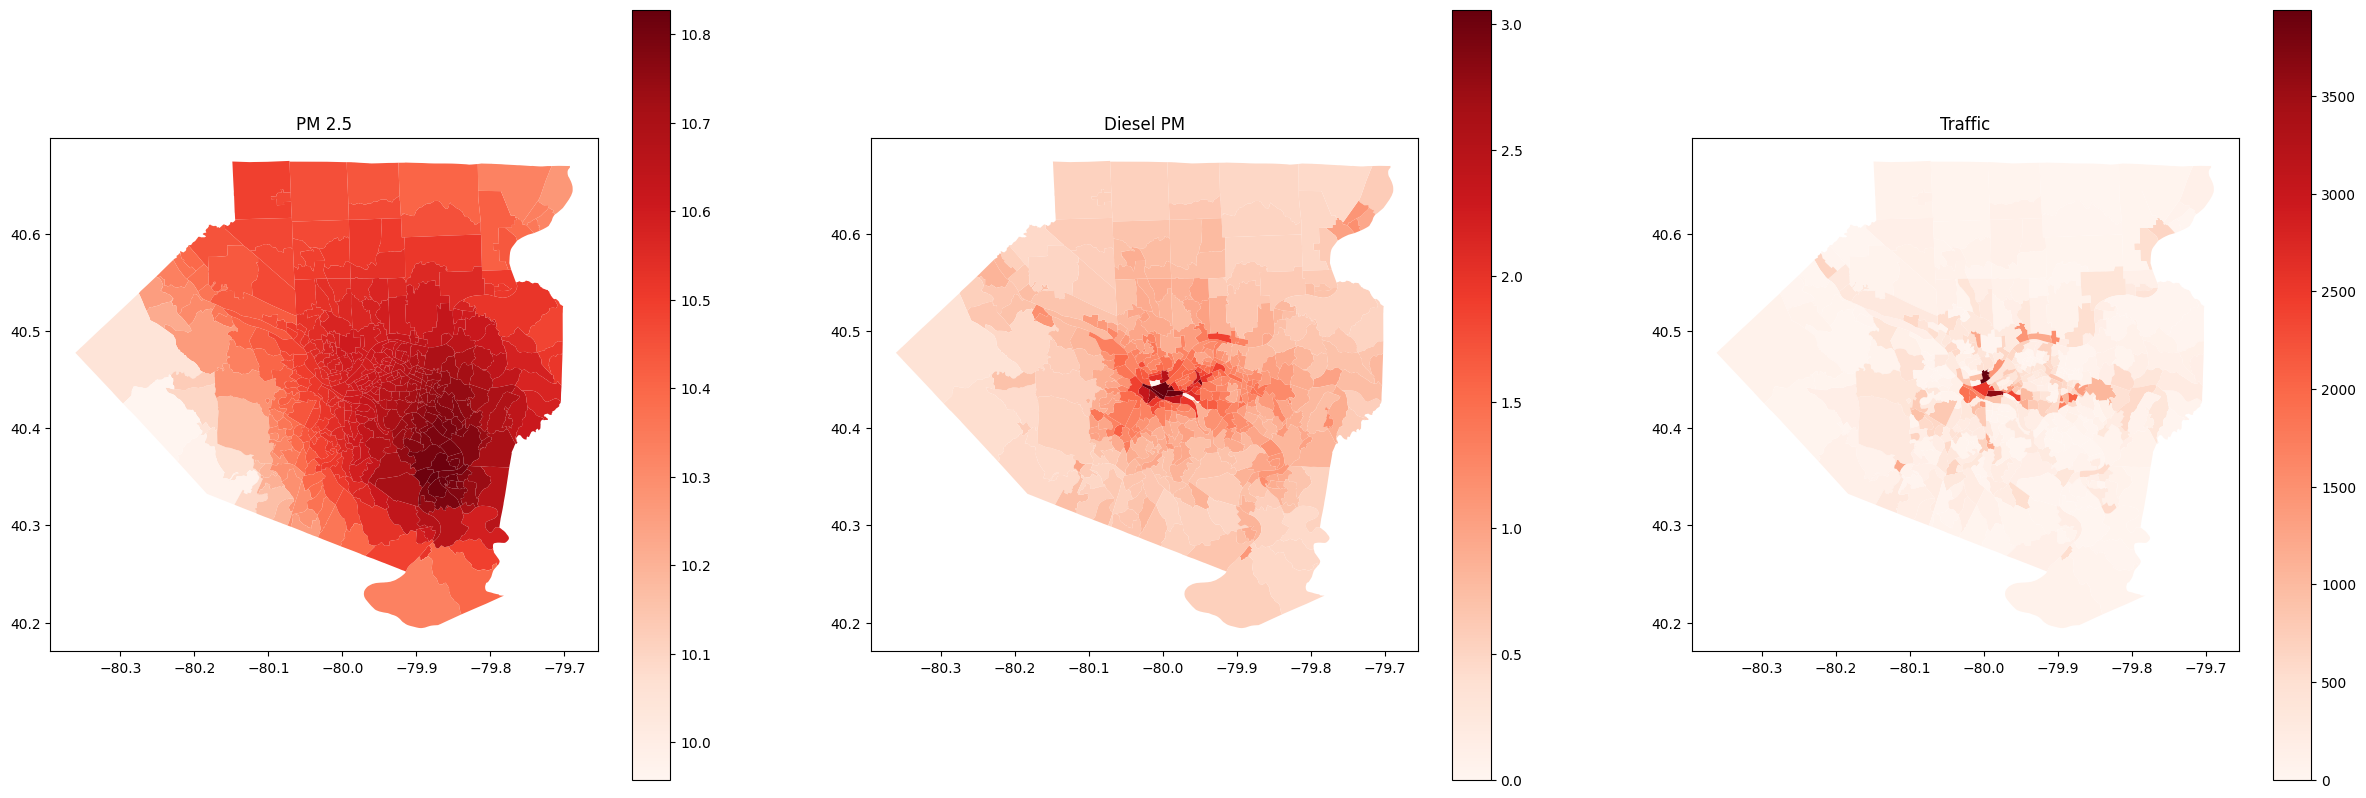

In [9]:
# plots of air quality related measures
fig, axs = plt.subplots(1, 3, figsize=(30, 10))
aq_gpd.plot(column="PM25", cmap="Reds", legend=True, ax=axs[0])
axs[0].set_title("PM 2.5")
aq_gpd.plot(column="dpm", cmap="Reds", legend=True, ax=axs[1])
axs[1].set_title("Diesel PM")
aq_gpd.plot(column="traffic", cmap="Reds", legend=True, ax=axs[2])
axs[2].set_title("Traffic")

# save the primary independent variables
indep_vars = ["PM25", "dpm", "traffic"]

- PM 2.5 has higher concentrations in the southeastern portion of Allegheny County. This corresponds to heavy industry in the Mon Valley, e.g. Clairton Coke Works, which are known emitters of PM 2.5.
- Diesel PM and traffic proximity seem to be concentrated near downtown Pittsburgh.

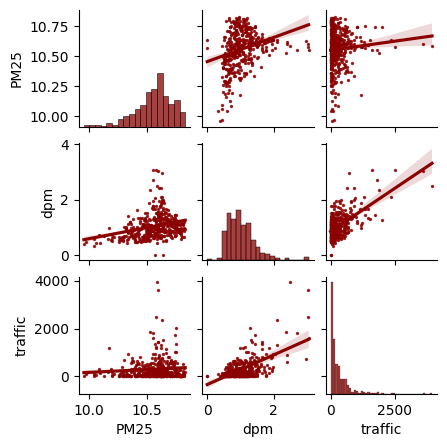

In [10]:
# plot relationships among the air quality variables
sns.pairplot(aq[indep_vars], height=1.5, kind="reg", 
             plot_kws={"scatter_kws":{"s": 2}, "color": "darkred"}, diag_kws={"color": "darkred"})

PM 2.5 and diesel PM have somewhat skew distributions, while distance to traffic is quite positively skewed. 

Diesel PM and traffic proximity are positively correlated, as expected from the regional plots above (and from expecting that the diesel PM originates in road traffic). Because these variables are strongly correlated, and diesel PM has a more normal distribution, I expect that I will want to use only diesel PM in my models. That being said, I will keep traffic proximity in the models for now, to see how it does.

PM 2.5 is positively correlated with diesel PM, but not with traffic proximity.

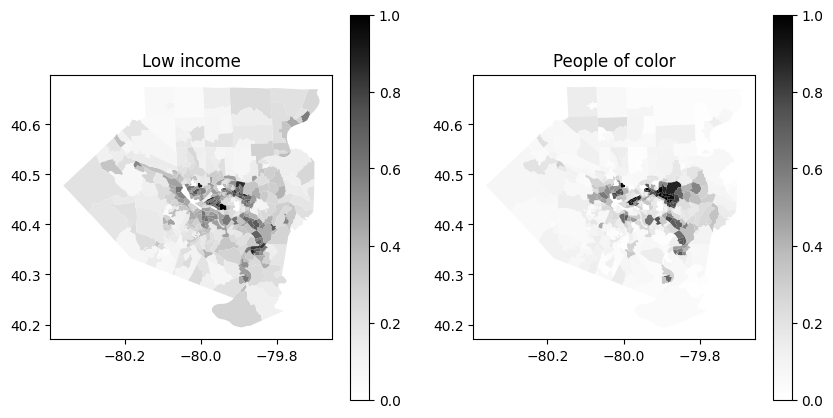

In [11]:
# plots of demographic measures
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
aq_gpd.plot(column="lowincome", cmap="Greys", legend=True, ax=axs[0])
axs[0].set_title("Low income")
aq_gpd.plot(column="poc", cmap="Greys", legend=True, ax=axs[1])
axs[1].set_title("People of color")

# save the demographic variables for later
demo_vars = ["lowincome", "poc"]

- Southeastern Allegheny County appears to have more residents who are low income, as well as more residents who are people of color.

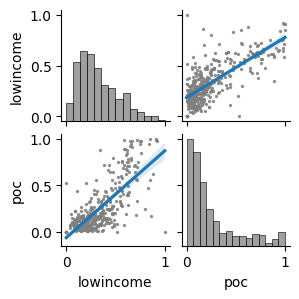

In [12]:
# plot relationships between the demographic variables
sns.pairplot(aq[demo_vars], height=1.5, kind="reg", 
             plot_kws={"scatter_kws":{"s": 2, "color": "grey"}}, diag_kws={"color": "grey"})

As unfortunately expected, there is a strong correlation between fraction POC and fraction low income residents.

## Asthma vs air quality

In [13]:
# merge asthma data with air quality / demographic data
df = asthma.merge(aq, left_on="Census_tract", right_on="ID", how="left", validate="1:1")
# put the geometry back in
df = tracts.merge(df, right_on="Census_tract", left_on="GEOID10", validate="1:1")
# add a column of ones to act as the intercept
df["intercept"] = 1

### Without controlling for demographics

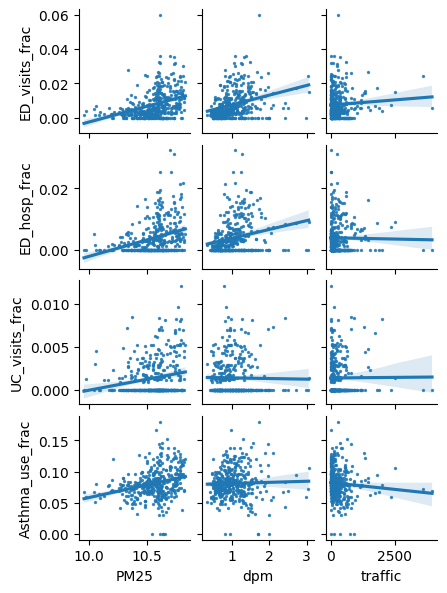

In [14]:
# quick picture of relationships between outcomes and air quality
sns.pairplot(df[dep_vars + indep_vars], x_vars=indep_vars, y_vars=dep_vars, 
             kind="reg", plot_kws={"scatter_kws":{"s": 2}}, height=1.5)

In [15]:
# linear regression, predicting asthma encounter fraction using average air quality measures as sole predictors
# these are the same as the regressions in the images above
all_res = list()
for indep in indep_vars:
    ols_res = dict()
    for dep in dep_vars:
        mod = sm.OLS(df[dep], df[[indep] + ["intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p"]])
pd.concat(all_res).style.pipe(p_col_style)

,,coef,std err,p
dep_var,indep_var,,,
ED_visits_frac,PM25,0.018370,0.002406,0.000
ED_hosp_frac,PM25,0.010794,0.001647,0.000
UC_visits_frac,PM25,0.002558,0.000678,0.000
Asthma_use_frac,PM25,0.040760,0.007527,0.000
ED_visits_frac,dpm,0.005643,0.000901,0.000
ED_hosp_frac,dpm,0.002869,0.000619,0.000
UC_visits_frac,dpm,-0.000073,0.000253,0.773
Asthma_use_frac,dpm,0.001756,0.002857,0.539
ED_visits_frac,traffic,0.000001,0.000001,0.192


Linear regression shows a significant relationship between PM 2.5 and all asthma encounter fractions, with worse air quality associated with more children having asthma-related medical encounters.

Diesel PM is associated with more children with emergency department visits and hospitalizations, but not lower acuity care. This result may reflect that diesel PM is associated with acute respiratory distress more than chronic conditions. (TODO is this supported by the literature?)

Traffic proximity isn't significantly associated with any outcome, Recalling the distribution of the traffic data, I also tried using the log of the traffic proximity, to generate a more normally distributed variable. (TODO make an aux notebook) That did improve regression results, but not enough to justify including traffic proximity in the following models.

What if we include PM 2.5 and diesel PM as predictors together? We will lose power, and we previously saw that PM 2.5 and diesel PM are (TODO significantly) positively correlated. However, I am interested to know in particular if the predictive power of PM 2.5 observed for the emergency department encounters comes only from association with higher diesel PM.

In [16]:
indep_vars = ["PM25", "dpm"]

for dep in dep_vars:
    mod = sm.OLS(df[dep], df[indep_vars + ["intercept"]])
    res = mod.fit()
    ols_res[dep] = res

ols2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

We reproduce the simple linear regression results, confirming the results that
- PM 2.5 is predictive of all 4 outcomes
- diesel PM is predictive of emergency department outcomes

Going forward, we will include diesel PM as a predictor only for the emergency department outcomes.

In [17]:
indep_to_use = {"ED_visits_frac": ["PM25", "dpm"],
                "ED_hosp_frac": ["PM25", "dpm"],
                "UC_visits_frac": ["PM25"],
                "Asthma_use_frac": ["PM25"]}

### Demographics vs air quality

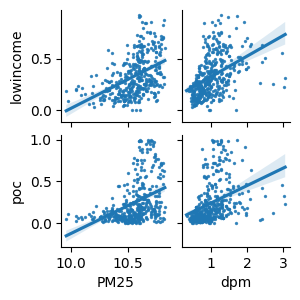

In [18]:
# quick picture of relationships between demographics and air quality
sns.pairplot(df[demo_vars + indep_vars], x_vars=indep_vars, y_vars=demo_vars, 
             kind="reg", plot_kws={"scatter_kws":{"s": 2}}, height=1.5)

There is are significant relationships between the air quality measures and the demographic measures (regression coefficients and p-values not shown). Unfortunately (again) we see higher air pollution in areas with higher proportions of POC and low-income residents.

Given that there is a correlation between air quality and our demographics, to what extent are our results due to demographics versus air quality?

### Controlling for demographics

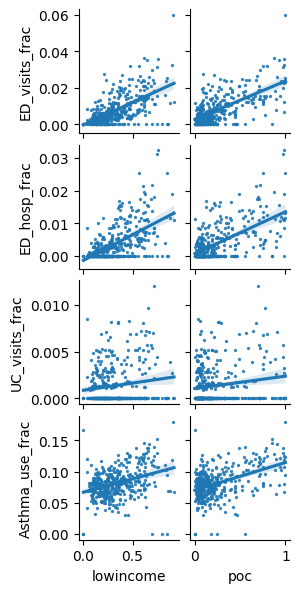

In [29]:
# quick picture of relationships between outcomes and demographics
sns.pairplot(df[dep_vars + demo_vars], x_vars=demo_vars, y_vars=dep_vars, 
             kind="reg", plot_kws={"scatter_kws":{"s": 2}}, height=1.5)

In [19]:
# reproduce the regressions above, using the demographic variables on their own as predictors
all_res = list()
for indep in demo_vars:
    ols_res = dict()
    for dep in dep_vars:
        mod = sm.OLS(df[dep], df[[indep] + ["intercept"]])
        res = mod.fit()
        ols_res[dep] = res
    all_res.append(ols2df(ols_res)[["coef", "std err", "p"]])
pd.concat(all_res).style.pipe(p_col_style)

,,coef,std err,p
dep_var,indep_var,,,
ED_visits_frac,lowincome,0.024718,0.001639,0.000
ED_hosp_frac,lowincome,0.015653,0.001138,0.000
UC_visits_frac,lowincome,0.001539,0.000546,0.005
Asthma_use_frac,lowincome,0.042579,0.005852,0.000
ED_visits_frac,poc,0.021085,0.001187,0.000
ED_hosp_frac,poc,0.012850,0.000854,0.000
UC_visits_frac,poc,0.001328,0.000422,0.002
Asthma_use_frac,poc,0.044322,0.004275,0.000


All the demographic variables are also significant predictors of all asthma encounter fractions. Higher proportions of low income and PoC residents are predictive of higher childhood asthma medical encounter rates.

Does air quality remain predictive of asthma outcomes when controlling for demographics? Or are demographics the driving predictor of asthma outcomes while being correlated with air quality?

In [20]:
# linear regression, predicting asthma encounter fraction using average PM 2.5 concentration as well as demographics
ols_res = dict()
for col in dep_vars:
    mod = sm.OLS(df[col], df[indep_to_use[col] + demo_vars + ["intercept"]])
    res = mod.fit()
    ols_res[col] = res
ols2df(ols_res)[["coef", "std err", "p"]].style.pipe(p_col_style)

For emergency department visits and hospitalizations, PM 2.5 and diesel PM are no longer significant predictors when low income and PoC covariates are included. However, higher fractions of both low income and PoC residents predict higher rates of emergency department utilization for childhood asthma. I suspect this result reflects that lower income residents and PoC residents have less access to non-emergency medical services than higher income and white residents. These residents therefore are more likely to be seen in the emergency department rather than urgent or primary care. They may have higher rates of ED hospitalization due to lack of access to preventative care leading to higher acuity cases.

PM 2.5 remains a significant predictor of urgent care visits as well as overall medical encounters related to childhood asthma. In areas with higher average annual concentrations of PM 2.5, a higher fraction of children receive medical attention for asthma, even when controlling for low income and PoC resident proportions. 

### Spatial autocorrelation

The linear regressions above assume that observations are independent of each other. However, I have good reason to believe that they are not, since there are apparent spatial structures in the variables. Particularly for PM 2.5, I would be suprised if there wasn't spatial autocorrelation in the data: areas close to each other are expected to have more similar air than areas further away.

I first want to determine, statistically, if our variables are spatially autocorrelated. I will use Moran's I, with Queen contiguity as weights.

In [21]:
# spatial lag weights from Queen contiguity
w = Queen.from_dataframe(df, use_index=False)
# standardize by rows
w.transform = "R"
# compute Moran's I
res_dict = {}
for col in ["PM25", "dpm", "lowincome", "poc"] + dep_vars:
    moran = Moran(df[col], w)
    res_dict[col] = {"I": moran.I, "p": moran.p_sim}
res = pd.DataFrame(res_dict).transpose()
res

,I,p
PM25,0.957093,0.001
dpm,0.778897,0.001
lowincome,0.553072,0.001
poc,0.652880,0.001
ED_visits_frac,0.412046,0.001
ED_hosp_frac,0.308218,0.001
UC_visits_frac,0.139003,0.001
Asthma_use_frac,0.239554,0.001


All of the predictors and outcomes are significantly spatially autocorrelated.

- In the predictors/independent variables, autocorrelation may lead to underestimation of coefficient confidence intervals, causing predictors to appear significant that actually aren't. I am in esssence "double counting" the effect of each autocorrelated predictor, because measurements from adjacent census tracts are similar to each other.
- Autocorrelation of the outcomes/dependent variables may lead to a biased (aka just plain wrong) estimates of model coefficients.

One way to handle spatial autocorrelation is to include spatial lag in the model formulation. There are several common ways of incorporating spatial lag:
- TODO Include pre-computed spatial lags of the independent variables in the linear regression (for independent variable spatial autocorrelation)
- Include spatial lag in the error term of the linear regression (for independent variable spatial autocorrelation)
- Include spatial lag of the dependent variable in the linear regression (for dependent variable spatial autocorrelation)

TODO what about both independent and dependent variables?

In [22]:
# Spatial lag in the error term, fit using
# general method of moments estimation allowing for heteroskedasticity
#
# This is a general method that allows us to choose the weights used to compute the error term, 
# in this case the same spatial lag weights computed above

# start without controlling for demographics
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep]
    res = spreg.GM_Error_Het(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict)[["coef", "std err", "p"]].style.pipe(p_col_style)

As before, air quality is a significant predictor of all measures of childhood asthma, even accounting for the effect of spatial autocorrelation of air quality measures.

The spatial lag error term coefficient `lambda` is also significant for every model except when predicting overall asthma use. This suggests that the spatial autocorrelation of air quality likely did cause underestimation of the confidence intervals in the previous models. TODO check my understanding on this

How do these effects hold up to controlling for demographic covariates?

In [23]:
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep] + ["lowincome", "poc"]
    res = spreg.GM_Error_Het(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict)[["coef", "std err", "p"]].style.pipe(p_col_style)

Air quality loses significance as a predictor of ED hospitalizations and overall asthma related encounters. However, the fraction of low income and PoC residents remains significant for ED visits and hospitalizations.

The spatial lag term `lambda` is significant for all outcomes except ED hospitalizations.

Recall that for the original models (without spatial lag), only the urgent care visits and overall asthma use remained significant after controlling for demographics.

What about if we control for spatial autocorrelation in the dependent variables?

In [26]:
# Spatial lag in the dependent variable, fit using
# general method of moments estimation allowing for dependent variable lag
#
# This is a general method that allows us to choose the weights used to lag the dependent variable,
# in this case the same spatial lag weights computed above

# start without controlling for demographics
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep]
    res = spreg.GM_Lag(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict, name_attr="name_z")[["coef", "std err", "p"]].style.pipe(p_col_style)

In [27]:
res_dict = dict()
for dep in dep_vars:
    indep = indep_to_use[dep] + ["lowincome", "poc"]
    res = spreg.GM_Lag(df[[dep]].values, df[indep].values, w=w, name_y=dep, name_x=indep)
    res_dict[dep] = res
spreg2df(res_dict, name_attr="name_z")[["coef", "std err", "p"]].style.pipe(p_col_style)